## Credit Risk Modelling - German Credit Dataset
This notebook builds a logistic regression model to predict credit default risk.
We cover data preprocessing, model training, evaluation and threshold tuning.

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, precision_score, recall_score, confusion_matrix
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings('ignore', category=ConvergenceWarning)
# warnings.filterwarnings('ignore', category=FutureWarning)

pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [43]:
import os
print(os.getcwd())
print(os.listdir())

c:\Users\User\Desktop\CreditRiskLearning\Exploration
['exploration.ipynb', 'modelling.ipynb']


### 1. Load and Prepare Data
Load the German Credit dataset and immediately map the target variable to binary (0/1).
Target mapping must happen before any splits to avoid data leakage.
- 0 = Good credit (no default)
- 1 = Bad credit (default)

In [44]:
# Build path relative to notebook location
base_path = os.path.dirname(os.path.abspath('exploration.ipynb'))
data_path = os.path.join(base_path, 'German Credit Data', 'german.data')


In [45]:
columns = [
    'checking_status', 'duration', 'credit_history', 'purpose', 'credit_amount',
    'savings', 'employment', 'installment_rate', 'personal_status', 'other_debtors',
    'residence_since', 'property', 'age', 'other_installments', 'housing',
    'existing_credits', 'job', 'dependents', 'telephone', 'foreign_worker', 'target'
]



### 2. Encode Categorical Variables
Machine learning models require numerical inputs. We use one hot encoding to convert 
categorical variables into binary columns. drop_first=True removes one redundant column 
per category to avoid multicollinearity (the dummy variable trap).

In [46]:
# Load data
df = pd.read_csv('../German Credit Data/german.data', sep=' ', header=None, names=columns)

# Map target FIRST before anything else
df['target'] = df['target'].map({1: 0, 2: 1})

# Verify it worked
print(df['target'].unique())  # should show [0 1]

# Then encode
cat_columns = df.select_dtypes(include='object').columns.tolist()
df_encoded = pd.get_dummies(df, columns=cat_columns, drop_first=True)

# Then split
X = df_encoded.drop('target', axis=1)
y = df_encoded['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verify split target values
print(y_test.unique())  # should show [0 1]

[0 1]
[1 0]


C:\Users\User\AppData\Local\Temp\ipykernel_22188\195248330.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_columns = df.select_dtypes(include='object').columns.tolist()


In [47]:
df.dtypes

checking_status         str
duration              int64
credit_history          str
purpose                 str
credit_amount         int64
savings                 str
employment              str
installment_rate      int64
personal_status         str
other_debtors           str
residence_since       int64
property                str
age                   int64
other_installments      str
housing                 str
existing_credits      int64
job                     str
dependents            int64
telephone               str
foreign_worker          str
target                int64
dtype: object

In [48]:
# Get list of categorical items
cat_columns = df.select_dtypes(include='str').columns.tolist()
print(cat_columns)

# One hoit encode items
df_encoded = pd.get_dummies(df, columns=cat_columns, drop_first=True)

print(f'Original shape: {df.shape}')
print(f'Encoded shape: {df_encoded.shape}')

['checking_status', 'credit_history', 'purpose', 'savings', 'employment', 'personal_status', 'other_debtors', 'property', 'other_installments', 'housing', 'job', 'telephone', 'foreign_worker']
Original shape: (1000, 21)
Encoded shape: (1000, 49)


### 3. Train Test Split
Split data into training (80%) and test (20%) sets.
- Training set: model learns from this data
- Test set: simulates unseen real world data for evaluation
random_state=42 ensures reproducible splits across machines.

In [49]:
# Split into features and target
X = df_encoded.drop('target', axis=1)
y = df_encoded['target']


# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Training rows: {X_train.shape[0]}')
print(f'Testing rows: {X_test.shape[0]}')

Training rows: 800
Testing rows: 200


In [50]:
# Build and train the model

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# Make predictions

y_pred = lr_model.predict(X_test)

print('Model trained successfully!')


Model trained successfully!


### 4. Scale Features
Logistic regression is sensitive to feature scale. Without scaling, high magnitude 
features like credit_amount would be overweighted vs low magnitude features like age.
StandardScaler fits ONLY on training data to prevent data leakage - 
we never let the model peek at test data during preprocessing.

In [51]:
from sklearn.preprocessing import StandardScaler

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Retrain with scaled data and more iterations

lr_model = LogisticRegression(max_iter = 2000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

y_pred = lr_model.predict(X_test_scaled)

print('Model trained successfully!')

Model trained successfully!


### 6. Model Evaluation
Evaluate model performance using precision, recall and f1-score.
In credit risk, recall on defaulters is the critical metric:
- High recall = catching more bad loans (reduces financial loss)
- High precision = fewer good customers wrongly rejected (reduces lost revenue)
The right balance depends on the business context and loan product.

In [52]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.88      0.86       141
           1       0.67      0.59      0.63        59

    accuracy                           0.80       200
   macro avg       0.76      0.74      0.74       200
weighted avg       0.79      0.80      0.79       200



### 7. Threshold Tuning
By default, logistic regression classifies at threshold 0.5.
Lowering the threshold increases recall (catch more defaulters) at the cost of precision.
For a mortgage lender, high recall is critical - one missed default on a $500k loan
far outweighs the cost of rejecting a good customer.

In [53]:
# Get probabilities instead of hard predictions

y_prob = lr_model.predict_proba(X_test_scaled)[:, 1]

# Try a lower threshold

threshold = 0.4
y_pred_tuned = (y_prob >= threshold).astype(int)

print(f'Results at threshold {threshold}:')
print(classification_report(y_test, y_pred_tuned))


Results at threshold 0.4:
              precision    recall  f1-score   support

           0       0.87      0.82      0.85       141
           1       0.63      0.71      0.67        59

    accuracy                           0.79       200
   macro avg       0.75      0.77      0.76       200
weighted avg       0.80      0.79      0.79       200



### 8. Precision-Recall Tradeoff
Systematically test every threshold from 0.1 to 0.9 to visualise the full tradeoff.
This informs the business decision about where to set the operating threshold,
which should be driven by the relative cost of false positives vs false negatives.

In [54]:
thresholds = np.arange(0.1, 0.9, 0.05)

results = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    recall = recall_score(y_test, y_pred_t, zero_division=0)
    precision = precision_score(y_test, y_pred_t, zero_division=0)
    results.append({'threshold': t, 'recall': recall, 'precision': precision})
    
results_df = pd.DataFrame(results)
print(results_df)

    threshold  recall  precision
0        0.10    0.93       0.37
1        0.15    0.88       0.40
2        0.20    0.86       0.45
3        0.25    0.83       0.49
4        0.30    0.76       0.53
5        0.35    0.75       0.59
6        0.40    0.71       0.63
7        0.45    0.61       0.64
8        0.50    0.59       0.67
9        0.55    0.54       0.73
10       0.60    0.46       0.73
11       0.65    0.44       0.79
12       0.70    0.32       0.76
13       0.75    0.22       0.76
14       0.80    0.15       0.82
15       0.85    0.10       0.86


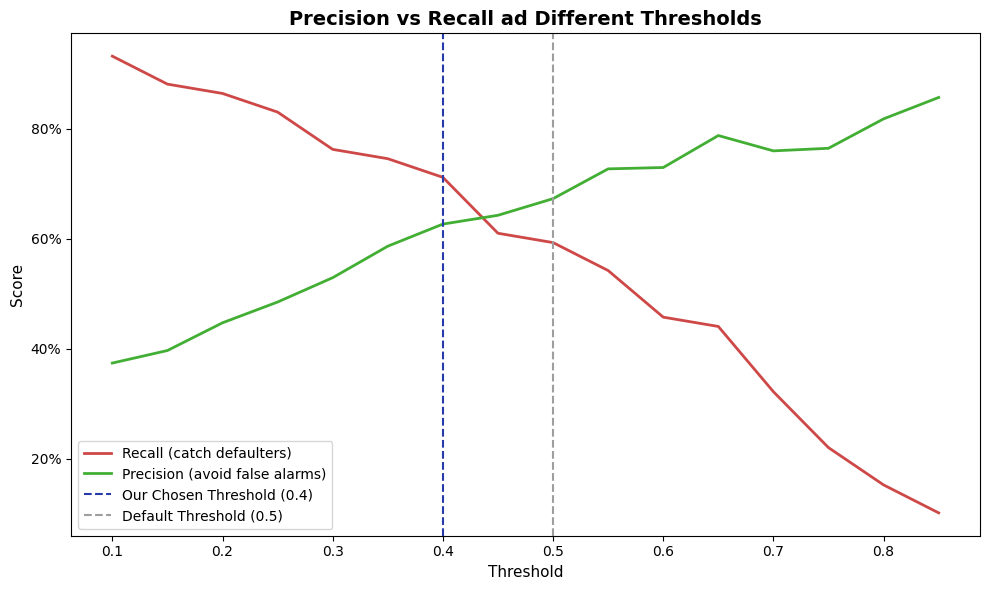

In [55]:
fig, ax = plt.subplots(figsize=(10,6))

ax.plot(results_df['threshold'], results_df['recall'],
        label='Recall (catch defaulters)', color="#CE4848", linewidth=2)
ax.plot(results_df['threshold'], results_df['precision'],
        label='Precision (avoid false alarms)', color="#42AF34", linewidth=2)
ax.axvline(x=0.4, color="#263AAA", linestyle='--', label='Our Chosen Threshold (0.4)')
ax.axvline(x=0.5, color="#9E9E9E", linestyle='--', label='Default Threshold (0.5)')

ax.set_title('Precision vs Recall ad Different Thresholds', fontsize=14, fontweight='bold')
ax.set_xlabel('Threshold', fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.legend()
plt.tight_layout()
plt.show()

### 9. Plotly vs Matplotlib

In [56]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(x=results_df['threshold'], y=results_df['recall'],
                          name='Recall', line=dict(color='red', width=2)))
fig.add_trace(go.Scatter(x=results_df['threshold'], y=results_df['precision'],
                          name='Precision', line=dict(color='green', width=2)))

fig.add_vline(x=0.4, line_dash='dash', line_color='blue', annotation_text='Our threshold')
fig.add_vline(x=0.5, line_dash='dash', line_color='grey', annotation_text='Default threshold')

fig.update_layout(
    title='Precision vs Recall at Different Thresholds',
    xaxis_title='Threshold',
    yaxis_title='Score',
    yaxis_tickformat='.0%',
    hovermode='x unified'
)

fig.show()

### Feature Importance

In [57]:
feature_importance = pd.DataFrame({
    'feature' : X.columns,
    'coefficient': lr_model.coef_[0]
})

feature_importance['abs_coefficient'] = feature_importance['coefficient'].abs()
feature_importance = feature_importance.sort_values('abs_coefficient', ascending=False)

print(feature_importance.head(15))


                    feature  coefficient  abs_coefficient
9       checking_status_A14        -0.78             0.78
13       credit_history_A34        -0.64             0.64
14              purpose_A41        -0.49             0.49
32      personal_status_A93        -0.45             0.45
17              purpose_A43        -0.42             0.42
1             credit_amount         0.37             0.37
16              purpose_A42        -0.35             0.35
2          installment_rate         0.35             0.35
44                 job_A173         0.34             0.34
4                       age        -0.32             0.32
40  other_installments_A143        -0.29             0.29
11       credit_history_A32        -0.28             0.28
12       credit_history_A33        -0.28             0.28
26              savings_A65        -0.27             0.27
45                 job_A174         0.26             0.26


### Top Features Visualisation

In [73]:
def clean_features(parts):
    
    clean = [p for p in parts if not (p.startswith('A') and p[1:].isdigit())]
    return ' '.join(clean).title()

top_features = feature_importance.head(15).reset_index(drop=True).copy()

top_features['feature_clean'] = top_features['feature'].str.split('_').apply(clean_features)

print(top_features[['feature', 'feature_clean']])
print(top_features)

                    feature       feature_clean
0       checking_status_A14     Checking Status
1        credit_history_A34      Credit History
2               purpose_A41             Purpose
3       personal_status_A93     Personal Status
4               purpose_A43             Purpose
5             credit_amount       Credit Amount
6               purpose_A42             Purpose
7          installment_rate    Installment Rate
8                  job_A173                 Job
9                       age                 Age
10  other_installments_A143  Other Installments
11       credit_history_A32      Credit History
12       credit_history_A33      Credit History
13              savings_A65             Savings
14                 job_A174                 Job
                    feature  coefficient  abs_coefficient       feature_clean
0       checking_status_A14        -0.78             0.78     Checking Status
1        credit_history_A34        -0.64             0.64      Credit Histor

<function matplotlib.pyplot.show(close=None, block=None)>

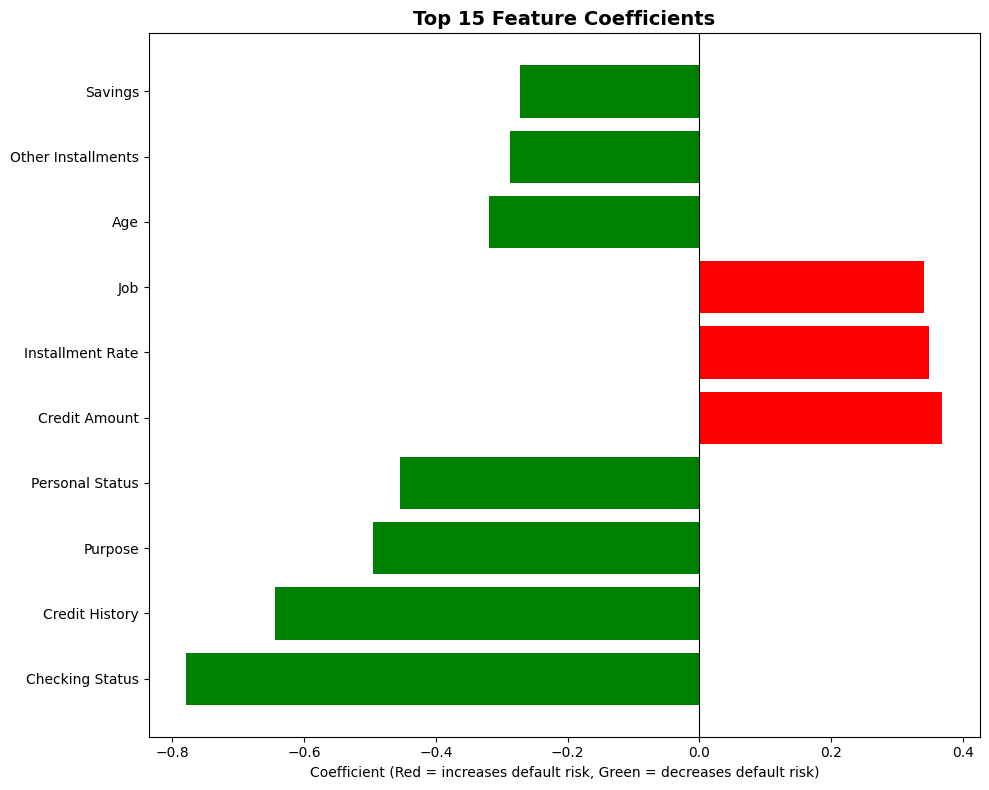

In [77]:

fig, ax = plt.subplots(figsize=(10,8))

colors = ['red' if c > 0 else 'green' for c in top_features['coefficient']]

ax.barh(top_features['feature_clean'], top_features['coefficient'], color=colors)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Top 15 Feature Coefficients', fontsize=14, fontweight='bold')
ax.set_xlabel('Coefficient (Red = increases default risk, Green = decreases default risk)', fontsize=10)

plt.tight_layout()
plt.show

### Feature Breakdown by Category

In [79]:
print(feature_importance[feature_importance['feature'].str.startswith('job')][['feature', 'coefficient']])
print(feature_importance[feature_importance['feature'].str.startswith('personal')][['feature', 'coefficient']])

     feature  coefficient
44  job_A173         0.34
45  job_A174         0.26
43  job_A172         0.22
                feature  coefficient
32  personal_status_A93        -0.45
31  personal_status_A92        -0.19
33  personal_status_A94        -0.10


### Removing Reference Category Distortion

In [ ]:
job_map = { 
    	  'A171' : 'unemployed/ unskilled  - non-resident',
	      'A172' : 'unskilled - resident',
	      'A173' : 'skilled employee / official',
	      'A174' : 'management/ self-employed/highly qualified employee/ officer'
}

df.groupby(df['job'].map(job_map))['target'].mean().sort_values(ascending=False)

TypeError: 'str' object is not callable